# Pretrained Transformer — DistilBERT

This notebook fine-tunes a pretrained DistilBERT model for binary sentiment
classification on the IMDB dataset.

The experiment uses the same data split established for the other models:

- Training: 20,000 reviews
- Validation: 5,000 reviews
- Test: 25,000 reviews

The test set remains untouched until final evaluation.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

C:\Users\Dell\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## reproducibility

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed:", SEED)

Seed: 42


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
## experiment configuration

MODEL_NAME = "distilbert/distilbert-base-uncased"

MAX_LENGTH = 500

BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 2

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

EPOCHS = 3
WARMUP_RATIO = 0.1

CHECKPOINT_DIR = Path("checkpoints/pretrained_transformer")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT = CHECKPOINT_DIR / "distilbert_best.pt"

print("Model:", MODEL_NAME)
print("Max length:", MAX_LENGTH)
print("Batch size:", BATCH_SIZE)
print("Gradient accumulation:", GRADIENT_ACCUMULATION_STEPS)
print("Effective batch size:",
      BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)

Model: distilbert/distilbert-base-uncased
Max length: 500
Batch size: 8
Gradient accumulation: 2
Effective batch size: 16
Learning rate: 2e-05
Epochs: 3


In [5]:
## load the data set

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [13]:
## splits

train_texts, val_texts, train_labels, val_labels = train_test_split(
    dataset["train"]["text"],
    dataset["train"]["label"],
    test_size=0.2,
    random_state=42,
    stratify=dataset["train"]["label"],
)

test_texts = list(dataset["test"]["text"])
test_labels = list(dataset["test"]["label"])

In [14]:
print("Train:", len(train_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))

Train: 20000
Validation: 5000
Test: 25000


In [15]:
print(
    "Train positives:",
    sum(train_labels),
    "| negatives:",
    len(train_labels) - sum(train_labels),
)

print(
    "Validation positives:",
    sum(val_labels),
    "| negatives:",
    len(val_labels) - sum(val_labels),
)

print(
    "Test positives:",
    sum(test_labels),
    "| negatives:",
    len(test_labels) - sum(test_labels),
)

Train positives: 10000 | negatives: 10000
Validation positives: 2500 | negatives: 2500
Test positives: 12500 | negatives: 12500


In [16]:
## load the DistilBERT tokenizer

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded.")
print("Vocabulary size:", tokenizer.vocab_size)
print("PAD token:", tokenizer.pad_token)
print("PAD token ID:", tokenizer.pad_token_id)

Tokenizer loaded.
Vocabulary size: 30522
PAD token: [PAD]
PAD token ID: 0


In [17]:
## tokenization

def tokenize_texts(texts):
    return tokenizer(
        texts,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

In [18]:
print(type(train_texts))
print(type(val_texts))
print(type(test_texts))

print(len(train_texts))
print(len(val_texts))
print(len(test_texts))

print(type(test_texts[0]))

<class 'list'>
<class 'list'>
<class 'list'>
20000
5000
25000
<class 'str'>


In [19]:
train_encodings = tokenize_texts(train_texts)
val_encodings = tokenize_texts(val_texts)
test_encodings = tokenize_texts(test_texts)

In [20]:
## dataset and dataloader

class IMDBTransformerDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        item = {
            key: torch.tensor(value[index], dtype=torch.long)
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[index],
            dtype=torch.long
        )

        return item

In [21]:
train_dataset = IMDBTransformerDataset(
    train_encodings,
    train_labels
)

val_dataset = IMDBTransformerDataset(
    val_encodings,
    val_labels
)

test_dataset = IMDBTransformerDataset(
    test_encodings,
    test_labels
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 20000
Validation dataset: 5000
Test dataset: 25000


In [22]:
## Dynamic padding and DataLoaders

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt",
)

In [23]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator,
)

In [24]:
batch = next(iter(train_loader))

for key, value in batch.items():
    print(f"{key}: shape={value.shape}, dtype={value.dtype}")

input_ids: shape=torch.Size([8, 500]), dtype=torch.int64
token_type_ids: shape=torch.Size([8, 500]), dtype=torch.int64
attention_mask: shape=torch.Size([8, 500]), dtype=torch.int64
labels: shape=torch.Size([8]), dtype=torch.int64


In [25]:
## inspecting a review

print("Input IDs:")
print(batch["input_ids"][0][:30])

print("\nAttention mask:")
print(batch["attention_mask"][0][:30])

print("\nLabel:")
print(batch["labels"][0])

Input IDs:
tensor([  101,  2023,  2003,  1037,  5621, 11113,  7274,  9067,  1036,  5843,
         4518,  1005, 17598,  2007,  1037, 17227,  3459,  1998,  1037,  6659,
         5896,  1012,  1045,  2031,  2053,  2801,  2339,  2061,  2116,  2327])

Attention mask:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1])

Label:
tensor(0)


In [26]:
## decoding back to text

decoded_text = tokenizer.decode(
    batch["input_ids"][0],
    skip_special_tokens=True
)

print(decoded_text[:500])

this is a truly abysmal ` lock stock ' clone with a stellar cast and a terrible script. i have no idea why so many top british actors signed up to this junk, they must have been bribed. a miss match of a storyline goes on forever and ever and ever and if i hadn ' t have paid good money for it i ' d have turned it off after 10 minutes. not the worst film ive ever seen, that honour goes to the truly pathetic used bogroll of a movie ' ( i use the term loosely ) ` gummo ' ( i feel like suing that so


In [27]:
##loaf pretrained DistilBERT

id2label = {
    0: "NEGATIVE",
    1: "POSITIVE",
}

label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1,
}

In [28]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

model = model.to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8333.44it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [29]:
## parameter count
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 66,955,010
Trainable parameters: 66,955,010


In [30]:
## forward pass smoke test

batch = next(iter(train_loader))

In [31]:
model.eval()

batch = {
    key: value.to(device)
    for key, value in batch.items()
}

with torch.no_grad():
    outputs = model(**batch)

print("Logits shape:", outputs.logits.shape)
print("Loss:", outputs.loss.item())
print("Logits:")
print(outputs.logits[:3])

Logits shape: torch.Size([8, 2])
Loss: 0.6805651187896729
Logits:
tensor([[ 0.0323, -0.0606],
        [ 0.0138, -0.0462],
        [ 0.0132, -0.0951]], device='cuda:0')


In [32]:
## fine tuning setup

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
EPOCHS = 3
GRADIENT_ACCUMULATION_STEPS = 2
WARMUP_RATIO = 0.1

In [33]:
import math

In [34]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

In [35]:
## Learning-rate scheduler

num_update_steps_per_epoch = math.ceil(
    len(train_loader) / GRADIENT_ACCUMULATION_STEPS
)

total_training_steps = (
    EPOCHS * num_update_steps_per_epoch
)

num_warmup_steps = int(
    WARMUP_RATIO * total_training_steps
)

print("Steps per epoch:", num_update_steps_per_epoch)
print("Total training steps:", total_training_steps)
print("Warmup steps:", num_warmup_steps)

Steps per epoch: 1250
Total training steps: 3750
Warmup steps: 375


In [36]:
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=total_training_steps,
)

In [ ]:
## training and validation funcitons

## move batch to gpu
def move_batch_to_device(batch):
    return {
        key: value.to(device)
        for key, value in batch.items()
    }

In [38]:
## training epoch

def train_one_epoch(
    model,
    train_loader,
    optimizer,
    scheduler,
    device,
    gradient_accumulation_steps=1,
):
    model.train()

    total_loss = 0.0
    total_samples = 0
    total_correct = 0

    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(train_loader):
        batch = move_batch_to_device(batch)

        outputs = model(**batch)

        loss = outputs.loss

        # Keep original loss for reporting
        batch_size = batch["labels"].size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        predictions = outputs.logits.argmax(dim=1)

        total_correct += (
            (predictions == batch["labels"])
            .sum()
            .item()
        )

        # Scale loss for gradient accumulation
        loss = loss / gradient_accumulation_steps

        loss.backward()

        is_accumulation_step = (
            (step + 1) % gradient_accumulation_steps == 0
        )

        is_last_batch = (
            step + 1 == len(train_loader)
        )

        if is_accumulation_step or is_last_batch:

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()
            scheduler.step()

            optimizer.zero_grad(set_to_none=True)

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy

In [39]:
## validation function

@torch.no_grad()
def validate(
    model,
    val_loader,
    device,
):
    model.eval()

    total_loss = 0.0
    total_samples = 0
    total_correct = 0

    for batch in val_loader:

        batch = move_batch_to_device(batch)

        outputs = model(**batch)

        loss = outputs.loss

        batch_size = batch["labels"].size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        predictions = outputs.logits.argmax(dim=1)

        total_correct += (
            (predictions == batch["labels"])
            .sum()
            .item()
        )

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy

In [40]:
## fine tuninig loop

best_model_dir = CHECKPOINT_DIR / "distilbert_best"
best_model_dir.mkdir(parents=True, exist_ok=True)

In [41]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

best_val_loss = float("inf")
best_epoch = None

for epoch in range(EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )
    print("-" * 50)

    train_loss, train_accuracy = train_one_epoch(
        model=model,
        train_loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    )

    val_loss, val_accuracy = validate(
        model=model,
        val_loader=val_loader,
        device=device,
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Acc:    {val_accuracy:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        model.save_pretrained(best_model_dir)
        tokenizer.save_pretrained(best_model_dir)

        print(
            f"✓ Best model saved "
            f"(epoch {best_epoch})"
        )


Epoch 1/3
--------------------------------------------------
Train Loss: 0.3145 | Train Acc: 0.8650
Val Loss:   0.2395 | Val Acc:    0.9206


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.68it/s]


✓ Best model saved (epoch 1)

Epoch 2/3
--------------------------------------------------
Train Loss: 0.1682 | Train Acc: 0.9456
Val Loss:   0.2287 | Val Acc:    0.9320


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.53it/s]


✓ Best model saved (epoch 2)

Epoch 3/3
--------------------------------------------------
Train Loss: 0.0936 | Train Acc: 0.9754
Val Loss:   0.2818 | Val Acc:    0.9344


In [42]:
print("\nBest epoch:", best_epoch)
print("Best validation loss:", best_val_loss)


Best epoch: 2
Best validation loss: 0.22872869049608707


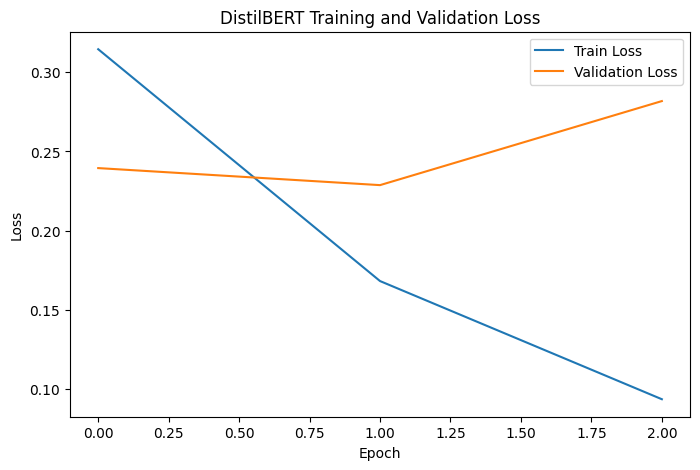

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss",
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT Training and Validation Loss")
plt.legend()

save_dir = "plots/pretrained_transformer/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "distilbert_training_validation_loss.png"), dpi=300, bbox_inches="tight")

plt.show()

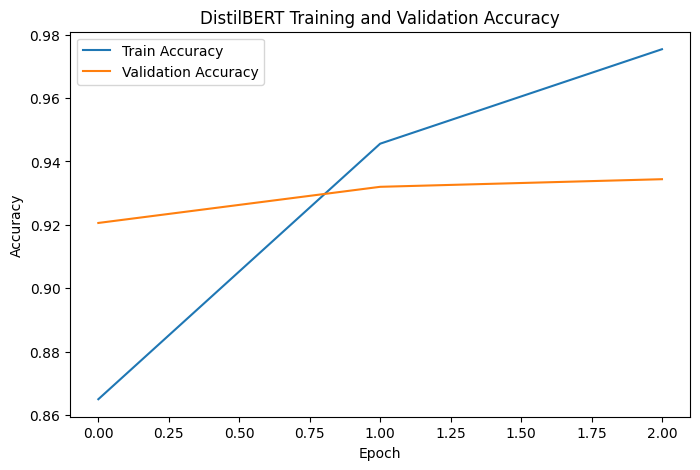

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_accuracy"],
    label="Train Accuracy",
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DistilBERT Training and Validation Accuracy")
plt.legend()

save_dir = "plots/pretrained_transformer/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "distilbert_training_validation_accuracy.png"), dpi=300, bbox_inches="tight")

plt.show()

In [45]:
## reload the epoch-2 checkpoint

from transformers import DistilBertForSequenceClassification

best_model = DistilBertForSequenceClassification.from_pretrained(
    best_model_dir
)

best_model = best_model.to(device)
best_model.eval()

print("Best DistilBERT checkpoint loaded.")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 4804.47it/s]


Best DistilBERT checkpoint loaded.


In [46]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

@torch.no_grad()
def predict_model(model, data_loader, device):

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    for batch in data_loader:

        batch = move_batch_to_device(batch)

        outputs = model(**batch)

        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_labels.extend(
            batch["labels"].cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        # Probability of positive class
        all_probabilities.extend(
            probabilities[:, 1].cpu().numpy()
        )

    return (
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities),
    )

In [47]:
test_labels, test_predictions, test_probabilities = predict_model(
    best_model,
    test_loader,
    device,
)

In [48]:
print("Number of test labels:", len(test_labels))
print("Number of predictions:", len(test_predictions))
print("Number of probabilities:", len(test_probabilities))

Number of test labels: 25000
Number of predictions: 25000
Number of probabilities: 25000


In [49]:
## calculate the final metrics

accuracy = accuracy_score(
    test_labels,
    test_predictions
)

precision = precision_score(
    test_labels,
    test_predictions
)

recall = recall_score(
    test_labels,
    test_predictions
)

f1 = f1_score(
    test_labels,
    test_predictions
)

roc_auc = roc_auc_score(
    test_labels,
    test_probabilities
)

cm = confusion_matrix(
    test_labels,
    test_predictions
)

print("DistilBERT Test Results")
print("-----------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

DistilBERT Test Results
-----------------------
Accuracy : 0.9297
Precision: 0.9216
Recall   : 0.9393
F1 Score : 0.9303
ROC-AUC  : 0.9798

Confusion Matrix:
[[11501   999]
 [  759 11741]]


#### Analysing errors

In [50]:
correct = test_predictions == test_labels
incorrect = ~correct

print("Total samples:", len(test_labels))
print("Correct:", correct.sum())
print("Incorrect:", incorrect.sum())

Total samples: 25000
Correct: 23242
Incorrect: 1758


In [51]:
## seperate false positives and false negatives

false_positives = (
    (test_labels == 0) &
    (test_predictions == 1)
)

false_negatives = (
    (test_labels == 1) &
    (test_predictions == 0)
)

true_positives = (
    (test_labels == 1) &
    (test_predictions == 1)
)

true_negatives = (
    (test_labels == 0) &
    (test_predictions == 0)
)

print("False positives:", false_positives.sum())
print("False negatives:", false_negatives.sum())
print("True positives:", true_positives.sum())
print("True negatives:", true_negatives.sum())

False positives: 999
False negatives: 759
True positives: 11741
True negatives: 11501


In [52]:
## examine the hardest mistakes

import pandas as pd

error_df = pd.DataFrame({
    "text": test_texts,
    "true_label": test_labels,
    "predicted_label": test_predictions,
    "probability": test_probabilities,
})

error_df["confidence"] = np.where(
    error_df["predicted_label"] == 1,
    error_df["probability"],
    1 - error_df["probability"]
)

errors = error_df[
    error_df["true_label"] != error_df["predicted_label"]
].copy()

In [53]:
## sort by confidence

most_confident_errors = errors.sort_values(
    "confidence",
    ascending=False
)

most_confident_errors.head(10)

,text,true_label,predicted_label,probability,confidence
8192,The Brave One is about a New York radio show h...,0,1,0.998309,0.998309
9543,"Lois Weber's film ""Hypocrites"" was and still k...",0,1,0.998299,0.998299
12061,This movie was pure genius. John Waters is bri...,0,1,0.998204,0.998204
4118,This is definitely one of the best Kung fu mov...,0,1,0.998074,0.998074
3757,"I went to see this 3 nights ago here in Cork, ...",0,1,0.998069,0.998069
7109,"This has to be one of, if not THE greatest Mob...",0,1,0.998051,0.998051
6245,Mickey Rourke hunts Diane Lane in Elmore Leona...,0,1,0.998020,0.998020
4811,With the plethora of repetitive and derivative...,0,1,0.997995,0.997995
7110,This is one entertaining flick. I suggest you ...,0,1,0.997988,0.997988
2160,There are those who gripe that this is NOT the...,0,1,0.997953,0.997953


In [54]:
## confidence statistics

print("Mean confidence - Correct:",
      error_df.loc[
          error_df["true_label"] == error_df["predicted_label"],
          "confidence"
      ].mean())

print("Mean confidence - Incorrect:",
      errors["confidence"].mean())

Mean confidence - Correct: 0.9804827
Mean confidence - Incorrect: 0.8743325


In [55]:
for threshold in [0.90, 0.95, 0.99]:

    count = (
        errors["confidence"] >= threshold
    ).sum()

    percentage = (
        count / len(errors) * 100
    )

    print(
        f"Errors with confidence >= {threshold:.0%}: "
        f"{count} ({percentage:.2f}%)"
    )

Errors with confidence >= 90%: 1052 (59.84%)
Errors with confidence >= 95%: 845 (48.07%)
Errors with confidence >= 99%: 347 (19.74%)


In [56]:
## fp vs fn confidence

fp_errors = errors[
    (errors["true_label"] == 0) &
    (errors["predicted_label"] == 1)
]

fn_errors = errors[
    (errors["true_label"] == 1) &
    (errors["predicted_label"] == 0)
]

In [57]:
print("False Positive confidence:")
print(fp_errors["confidence"].describe())

print("\nFalse Negative confidence:")
print(fn_errors["confidence"].describe())

False Positive confidence:
count    999.000000
mean       0.882855
std        0.141331
min        0.503404
25%        0.802534
50%        0.956856
75%        0.990861
max        0.998309
Name: confidence, dtype: float64

False Negative confidence:
count    759.000000
mean       0.863115
std        0.145025
min        0.500144
25%        0.781289
50%        0.927312
75%        0.980619
max        0.995656
Name: confidence, dtype: float64


In [58]:
for threshold in [0.90, 0.95, 0.99]:

    fp_count = (
        fp_errors["confidence"] >= threshold
    ).sum()

    fn_count = (
        fn_errors["confidence"] >= threshold
    ).sum()

    print(f"\nConfidence >= {threshold:.0%}")
    print("False positives:", fp_count)
    print("False negatives:", fn_count)


Confidence >= 90%
False positives: 622
False negatives: 430

Confidence >= 95%
False positives: 517
False negatives: 328

Confidence >= 99%
False positives: 261
False negatives: 86


In [59]:
test_encodings = tokenize_texts(test_texts)

test_token_lengths = [
    len(ids)
    for ids in test_encodings["input_ids"]
]

In [60]:
length_df = pd.DataFrame({
    "token_length": test_token_lengths,
    "correct": correct
})

print(length_df["token_length"].describe())

count    25000.000000
mean       269.477840
std        135.587366
min         10.000000
25%        166.000000
50%        230.000000
75%        372.000000
max        500.000000
Name: token_length, dtype: float64


In [61]:
long_reviews = length_df[
    length_df["token_length"] > 500
]

short_reviews = length_df[
    length_df["token_length"] <= 500
]

print(
    "Reviews longer than 500 tokens:",
    len(long_reviews)
)

print(
    "Error rate for >500 tokens:",
    1 - long_reviews["correct"].mean()
)

print(
    "Error rate for <=500 tokens:",
    1 - short_reviews["correct"].mean()
)

Reviews longer than 500 tokens: 0
Error rate for >500 tokens: nan
Error rate for <=500 tokens: 0.07032000000000005


In [62]:
def get_original_token_lengths(texts):
    encodings = tokenizer(
        texts,
        truncation=False,
        padding=False,
    )

    return [
        len(ids)
        for ids in encodings["input_ids"]
    ]

In [63]:
original_test_token_lengths = get_original_token_lengths(test_texts)

length_df = pd.DataFrame({
    "token_length": original_test_token_lengths,
    "correct": correct
})

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (532 > 512). Running this sequence through the model will result in indexing errors


In [64]:
long_reviews = length_df[
    length_df["token_length"] > 500
]

short_reviews = length_df[
    length_df["token_length"] <= 500
]

print("Reviews longer than 500 tokens:", len(long_reviews))
print(
    "Error rate for >500 tokens:",
    1 - long_reviews["correct"].mean()
)
print(
    "Error rate for <=500 tokens:",
    1 - short_reviews["correct"].mean()
)

Reviews longer than 500 tokens: 3699
Error rate for >500 tokens: 0.09867531765341986
Error rate for <=500 tokens: 0.06539599079855407


In [65]:
def get_token_lengths(texts):
    encodings = tokenizer(
        texts,
        truncation=False,
        padding=False,
    )
    
    return [len(ids) for ids in encodings["input_ids"]]

In [66]:
test_token_lengths = get_token_lengths(test_texts)

In [67]:
length_analysis = pd.DataFrame({
    "token_length": test_token_lengths,
    "correct": test_predictions == test_labels
})

In [68]:
length_analysis["length_group"] = pd.cut(
    length_analysis["token_length"],
    bins=[0, 500, float("inf")],
    labels=["<=500", ">500"]
)

print(length_analysis.groupby("length_group", observed=True)["correct"].apply(
    lambda x: 1 - x.mean()
))

length_group
<=500    0.065396
>500     0.098675
Name: correct, dtype: float64


In [69]:
## confidence values

import numpy as np
import pandas as pd

test_labels = np.array(test_labels)
test_predictions = np.array(test_predictions)
test_probabilities = np.array(test_probabilities)

confidence = np.where(
    test_predictions == 1,
    test_probabilities,
    1 - test_probabilities
)

correct = test_predictions == test_labels

confidence_analysis = pd.DataFrame({
    "true_label": test_labels,
    "prediction": test_predictions,
    "probability": test_probabilities,
    "confidence": confidence,
    "correct": correct
})

confidence_analysis.head()

,true_label,prediction,probability,confidence,correct
0,0,0,0.006740,0.993260,True
1,0,0,0.034078,0.965922,True
2,0,0,0.006185,0.993815,True
3,0,0,0.006124,0.993876,True
4,0,1,0.990898,0.990898,False


In [70]:
## correct vs incorrect confidence

print("Mean confidence - Correct:",
      confidence_analysis.loc[
          confidence_analysis["correct"], "confidence"
      ].mean())

print("Mean confidence - Incorrect:",
      confidence_analysis.loc[
          ~confidence_analysis["correct"], "confidence"
      ].mean())

Mean confidence - Correct: 0.9804827
Mean confidence - Incorrect: 0.8743325


In [71]:
## distributions

print("\nCorrect predictions:")
print(
    confidence_analysis.loc[
        confidence_analysis["correct"], "confidence"
    ].describe()
)

print("\nIncorrect predictions:")
print(
    confidence_analysis.loc[
        ~confidence_analysis["correct"], "confidence"
    ].describe()
)


Correct predictions:
count    23242.000000
mean         0.980483
std          0.056949
min          0.500121
25%          0.991342
50%          0.994798
75%          0.997409
max          0.998485
Name: confidence, dtype: float64

Incorrect predictions:
count    1758.000000
mean        0.874332
std         0.143231
min         0.500144
25%         0.793766
50%         0.944881
75%         0.986287
max         0.998309
Name: confidence, dtype: float64


In [72]:
## high confidence errors

errors = confidence_analysis[~confidence_analysis["correct"]]

for threshold in [0.90, 0.95, 0.99]:
    count = (errors["confidence"] >= threshold).sum()
    percentage = count / len(errors) * 100

    print(
        f"Confidence >= {threshold*100:.0f}%: "
        f"{count} ({percentage:.2f}%)"
    )

Confidence >= 90%: 1052 (59.84%)
Confidence >= 95%: 845 (48.07%)
Confidence >= 99%: 347 (19.74%)


In [73]:
false_positives = confidence_analysis[
    (confidence_analysis["true_label"] == 0) &
    (confidence_analysis["prediction"] == 1)
]

false_negatives = confidence_analysis[
    (confidence_analysis["true_label"] == 1) &
    (confidence_analysis["prediction"] == 0)
]

for threshold in [0.90, 0.95, 0.99]:

    fp_count = (false_positives["confidence"] >= threshold).sum()
    fn_count = (false_negatives["confidence"] >= threshold).sum()

    print(f"\nConfidence >= {threshold*100:.0f}%")
    print("False positives:", fp_count)
    print("False negatives:", fn_count)


Confidence >= 90%
False positives: 622
False negatives: 430

Confidence >= 95%
False positives: 517
False negatives: 328

Confidence >= 99%
False positives: 261
False negatives: 86


In [74]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(
    test_labels,
    test_probabilities
)

print(f"Brier Score: {brier:.4f}")

Brier Score: 0.0586


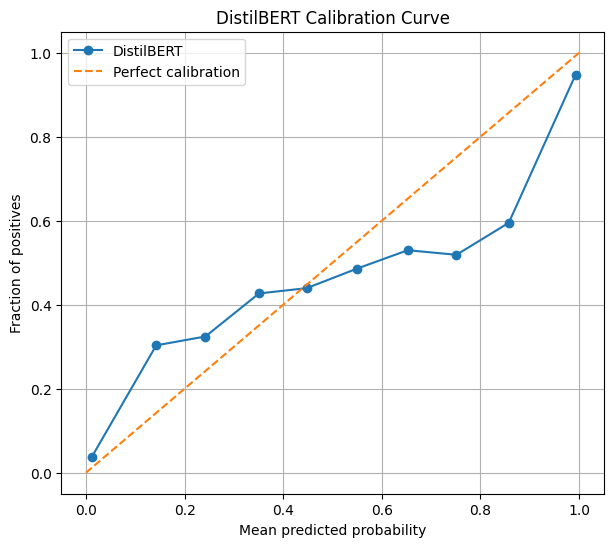

In [76]:
## calibration curve

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    test_labels,
    test_probabilities,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="DistilBERT"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("DistilBERT Calibration Curve")
plt.legend()
plt.grid(True)

save_dir = "plots/pretrained_transformer/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "distilbert_calibration_curve.png"), dpi=300, bbox_inches="tight")

plt.show()

In [77]:
## distilbert metrics

distilbert_results = {
    "Model": "DistilBERT",
    "Accuracy": 0.9297,
    "Precision": 0.9216,
    "Recall": 0.9393,
    "F1": 0.9303,
    "ROC-AUC": 0.9798,
    "Brier Score": 0.0586
}

In [78]:
model_results = [
    {
        "Model": "Simple RNN",
        "Accuracy": 0.7545,
        "Precision": 0.7668,
        "Recall": 0.7314,
        "F1": 0.7487,
        "ROC-AUC": 0.8202,
        "Brier Score": None
    },

    {
        "Model": "LSTM",
        "Accuracy": 0.8373,
        "Precision": 0.8191,
        "Recall": 0.8659,
        "F1": 0.8418,
        "ROC-AUC": 0.9124,
        "Brier Score": None
    },

    {
        "Model": "BiLSTM",
        "Accuracy": 0.8542,
        "Precision": 0.8641,
        "Recall": 0.8406,
        "F1": 0.8522,
        "ROC-AUC": 0.9324,
        "Brier Score": None
    },

    {
        "Model": "Transformer",
        "Accuracy": 0.8458,
        "Precision": 0.8470,
        "Recall": 0.8441,
        "F1": 0.8455,
        "ROC-AUC": 0.9261,
        "Brier Score": 0.1094
    },

    {
        "Model": "DistilBERT",
        "Accuracy": 0.9297,
        "Precision": 0.9216,
        "Recall": 0.9393,
        "F1": 0.9303,
        "ROC-AUC": 0.9798,
        "Brier Score": 0.0586
    }
]

comparison_df = pd.DataFrame(model_results)

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Brier Score
0,Simple RNN,0.7545,0.7668,0.7314,0.7487,0.8202,NaN
1,LSTM,0.8373,0.8191,0.8659,0.8418,0.9124,NaN
2,BiLSTM,0.8542,0.8641,0.8406,0.8522,0.9324,NaN
3,Transformer,0.8458,0.8470,0.8441,0.8455,0.9261,0.1094
4,DistilBERT,0.9297,0.9216,0.9393,0.9303,0.9798,0.0586


In [79]:
comparison_df = pd.DataFrame(model_results)

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Brier Score
0,Simple RNN,0.7545,0.7668,0.7314,0.7487,0.8202,NaN
1,LSTM,0.8373,0.8191,0.8659,0.8418,0.9124,NaN
2,BiLSTM,0.8542,0.8641,0.8406,0.8522,0.9324,NaN
3,Transformer,0.8458,0.8470,0.8441,0.8455,0.9261,0.1094
4,DistilBERT,0.9297,0.9216,0.9393,0.9303,0.9798,0.0586


In [80]:
## improvement over the original transformer

old_acc = 0.8458
new_acc = 0.9297

absolute_improvement = new_acc - old_acc
relative_improvement = (new_acc - old_acc) / old_acc * 100

print(f"Absolute improvement: {absolute_improvement:.4f}")
print(f"Relative improvement: {relative_improvement:.2f}%")

Absolute improvement: 0.0839
Relative improvement: 9.92%


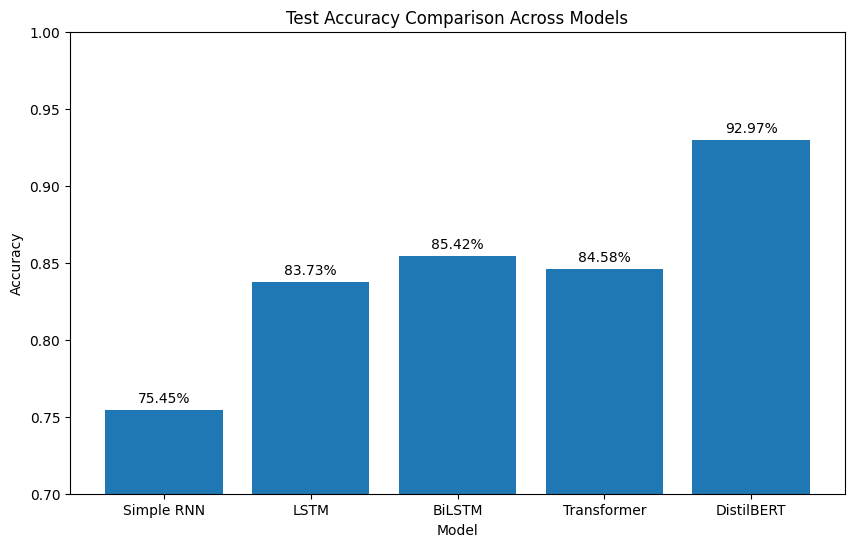

In [81]:
## visualizing all the models

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Test Accuracy Comparison Across Models")
plt.ylim(0.70, 1.00)

for i, value in enumerate(comparison_df["Accuracy"]):
    plt.text(
        i,
        value + 0.005,
        f"{value:.2%}",
        ha="center"
    )

save_dir = "plots/final_comp/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "test_accuracy_comparison.png"), dpi=300, bbox_inches="tight")

plt.show()

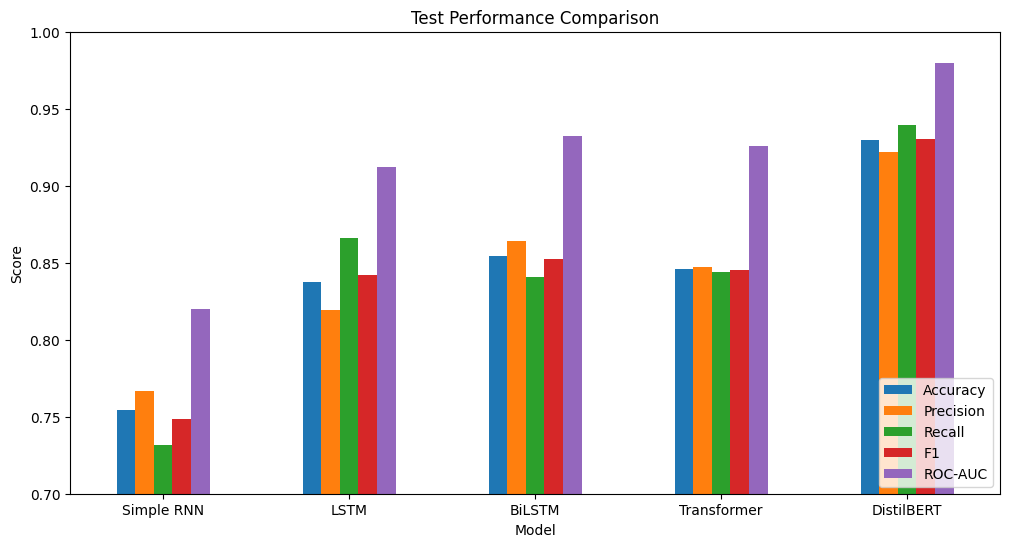

In [82]:
## comparison of all the classical metrics

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

comparison_plot = comparison_df.set_index("Model")[metrics]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Test Performance Comparison")
plt.ylim(0.70, 1.00)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

save_dir = "plots/final_comp/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "test_performance_comparison.png"), dpi=300, bbox_inches="tight")

plt.show()

In [83]:
## distilbert's improvement over every model

distilbert_row = comparison_df[
    comparison_df["Model"] == "DistilBERT"
].iloc[0]

baseline_models = comparison_df[
    comparison_df["Model"] != "DistilBERT"
]

improvement_rows = []

for _, row in baseline_models.iterrows():

    improvement_rows.append({
        "Compared With": row["Model"],
        "Accuracy Improvement": (
            distilbert_row["Accuracy"] - row["Accuracy"]
        ),
        "F1 Improvement": (
            distilbert_row["F1"] - row["F1"]
        ),
        "ROC-AUC Improvement": (
            distilbert_row["ROC-AUC"] - row["ROC-AUC"]
        )
    })

improvement_df = pd.DataFrame(improvement_rows)

improvement_df

,Compared With,Accuracy Improvement,F1 Improvement,ROC-AUC Improvement
0,Simple RNN,0.1752,0.1816,0.1596
1,LSTM,0.0924,0.0885,0.0674
2,BiLSTM,0.0755,0.0781,0.0474
3,Transformer,0.0839,0.0848,0.0537


In [84]:
##Ranking the models

ranking = comparison_df.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

ranking[[
    "Model",
    "Accuracy",
    "F1",
    "ROC-AUC"
]]

,Model,Accuracy,F1,ROC-AUC
0,DistilBERT,0.9297,0.9303,0.9798
1,BiLSTM,0.8542,0.8522,0.9324
2,Transformer,0.8458,0.8455,0.9261
3,LSTM,0.8373,0.8418,0.9124
4,Simple RNN,0.7545,0.7487,0.8202


In [85]:
## quantify the overall progression

for _, row in comparison_df.iterrows():
    print(
        f"{row['Model']:12s} | "
        f"Accuracy: {row['Accuracy']:.4f} | "
        f"F1: {row['F1']:.4f} | "
        f"ROC-AUC: {row['ROC-AUC']:.4f}"
    )

Simple RNN   | Accuracy: 0.7545 | F1: 0.7487 | ROC-AUC: 0.8202
LSTM         | Accuracy: 0.8373 | F1: 0.8418 | ROC-AUC: 0.9124
BiLSTM       | Accuracy: 0.8542 | F1: 0.8522 | ROC-AUC: 0.9324
Transformer  | Accuracy: 0.8458 | F1: 0.8455 | ROC-AUC: 0.9261
DistilBERT   | Accuracy: 0.9297 | F1: 0.9303 | ROC-AUC: 0.9798


In [2]:
import pandas as pd

final_model_results = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "BiLSTM",
        "Transformer",
        "DistilBERT"
    ],
    "Accuracy": [
        0.7545,
        0.8373,
        0.8542,
        0.8458,
        0.9297
    ],
    "Precision": [
        0.7668,
        0.8191,
        0.8641,
        0.8470,
        0.9216
    ],
    "Recall": [
        0.7314,
        0.8659,
        0.8406,
        0.8441,
        0.9393
    ],
    "F1": [
        0.7487,
        0.8418,
        0.8522,
        0.8455,
        0.9303
    ],
    "ROC-AUC": [
        0.8202,
        0.9124,
        0.9324,
        0.9261,
        0.9798
    ],
    "Brier Score": [
        None,
        None,
        None,
        0.1094,
        0.0586
    ]
})

final_model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Brier Score
0,Simple RNN,0.7545,0.7668,0.7314,0.7487,0.8202,NaN
1,LSTM,0.8373,0.8191,0.8659,0.8418,0.9124,NaN
2,BiLSTM,0.8542,0.8641,0.8406,0.8522,0.9324,NaN
3,Transformer,0.8458,0.8470,0.8441,0.8455,0.9261,0.1094
4,DistilBERT,0.9297,0.9216,0.9393,0.9303,0.9798,0.0586
